In [ ]:
%matplotlib inline

import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
import scienceplots


# ── 超参数 ────────────────────────────────────────────
N           = 31
Nx_total    = 3000
steady_idx  = 1500
num_trials  = 20
base_seed   = 451
sigma_x     = 1.0
Q_sigma     = 1e-3
R_sigma     = 1.0
P0_sigma    = 2.0
delta_rls   = 0.1
window      = 50
init_val    = 0.5

# ── 噪声分布 ──────────────────────────────────────────
def laplace_pdf(u):
    return torch.exp(-2**0.5 * u.abs()) * 2**0.5 / 2

def uniform_pdf(u):
    return torch.where(u.abs() <= 3**0.5,
                       torch.ones_like(u) / (2*3**0.5),
                       torch.zeros_like(u))

def laplace_cdf_np(u):
    return np.where(u >= 0,
                    1 - 0.5*np.exp(-2**0.5*u),
                    0.5*np.exp(2**0.5*u))

def uniform_cdf_np(u):
    return np.clip((u + 3**0.5) / (2*3**0.5), 0, 1)

noise_configs = {
    'Laplace': {
        'pdf_torch'  : laplace_pdf,
        'cdf_np'     : laplace_cdf_np,
        'sampler'    : lambda n: torch.from_numpy(
                           np.random.laplace(0, 1/2**0.5, n)).float(),
        'color'      : '#1f77b4',
        'light_color': lighten_color('#1f77b4', amount=0.25),
        'label'      : 'Laplace',
    },
    'Uniform': {
        'pdf_torch'  : uniform_pdf,
        'cdf_np'     : uniform_cdf_np,
        'sampler'    : lambda n: torch.from_numpy(
                           np.random.uniform(-3**0.5, 3**0.5, n)).float(),
        'color'      : '#c44e52',
        'light_color': lighten_color('#c44e52', amount=0.25),
        'label'      : 'Uniform',
    },
}

# ── 理论最优值 ────────────────────────────────────────
def fx_np(x):
    return np.exp(-x**2/(2*sigma_x**2)) / np.sqrt(2*np.pi*sigma_x**2)

def compute_theory(cdf_np):
    def h_bar(x, sigma): return 2*cdf_np(x/sigma) - 1
    def p_fn(sigma):
        return quad(lambda x: x*h_bar(x,sigma)*fx_np(x), -8, 8)[0]
    def psi_fn(sigma):
        return quad(lambda x: h_bar(x,sigma)**2*fx_np(x), -8, 8)[0]
    def mse_fn(sigma):
        p = p_fn(sigma); psi = psi_fn(sigma)
        return sigma_x**2 - N*p**2 / (1 + (N-1)*psi)
    res = minimize_scalar(mse_fn, bounds=(0.05, 4.0), method='bounded')
    return res.x, mse_fn(res.x)

# ── 因果滑动平均（修复初始MSE偏小的问题）────────────
def causal_moving_average(x, window):
    """
    Causal moving average: at time k, average only past 'window' samples.
    No zero-padding on the left, so initial values reflect true MSE.
    """
    out = np.zeros(len(x))
    cumsum = np.cumsum(x)
    for i in range(len(x)):
        if i < window:
            out[i] = cumsum[i] / (i + 1)   # 窗口不足时用所有历史数据
        else:
            out[i] = (cumsum[i] - cumsum[i-window]) / window
    return out

# ── 单次仿真 ──────────────────────────────────────────
def run_simulation(seed_val, init_sigma, pdf_torch, sampler):
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)

    input_data = torch.randn(Nx_total) * sigma_x
    W          = torch.tensor(1.0)
    P_rls      = torch.tensor(10.0)
    sigma_curr = torch.tensor(float(init_sigma))
    P_sigma    = torch.tensor(P0_sigma)
    sigma_hist = torch.zeros(Nx_total)
    mse_inst   = torch.zeros(Nx_total)

    for k in range(Nx_total):
        x_k = input_data[k]
        torch.manual_seed(seed_val + 3*k)
        np.random.seed(seed_val + 3*k)

        xi    = sampler(N).float()
        y_vec = torch.sign(x_k + sigma_curr * xi)
        phi_k = y_vec.mean()

        y_hat = W * phi_k
        e_k   = x_k - y_hat
        denom = phi_k**2 * P_rls + delta_rls
        g_rls = P_rls * phi_k / denom
        W     = W + g_rls * e_k
        P_rls = P_rls - g_rls * phi_k * P_rls

        s_safe = sigma_curr.clamp(min=0.01)
        u      = x_k / s_safe
        H_k    = -2.0 * W * (x_k / s_safe**2) * pdf_torch(u)

        P_pred  = P_sigma + Q_sigma
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov
        step    = (K_sigma * e_k).clamp(-0.2, 0.2)

        sigma_curr = (sigma_curr + step).clamp(0.03, 5.0)
        P_sigma    = (1 - K_sigma * H_k) * P_pred

        sigma_hist[k] = sigma_curr.item()
        mse_inst[k]   = e_k.item()**2

    # 因果滑动平均（不补零）
    win_mse = causal_moving_average(mse_inst.numpy(), window)

    return sigma_hist.numpy(), win_mse

# ── 主循环 ────────────────────────────────────────────
print("Running simulations (Laplace & Uniform, "
      f"sigma_0={init_val}, {num_trials} trials)...")

results     = {}
theory_vals = {}

for name, cfg in noise_configs.items():
    sigma_opt, mse_opt = compute_theory(cfg['cdf_np'])
    theory_vals[name]  = (sigma_opt, mse_opt)

    sigma_trajs, mse_trajs = [], []
    for t in range(num_trials):
        sh, wm = run_simulation(
            base_seed + t, init_val,
            cfg['pdf_torch'], cfg['sampler']
        )
        sigma_trajs.append(sh)
        mse_trajs.append(wm)

    sigma_arr = np.array(sigma_trajs)
    mse_arr   = np.array(mse_trajs)
    results[name] = {
        'sigma_mean': sigma_arr.mean(axis=0),
        'sigma_std' : sigma_arr.std(axis=0),
        'mse_mean'  : mse_arr.mean(axis=0),
        'mse_std'   : mse_arr.std(axis=0),
    }
    print(f"  {name:<8}: sigma*={sigma_opt:.4f}, "
          f"MSE_th={mse_opt:.5f}  [done]")

# ── 绘图 ─────────────────────────────────────────────

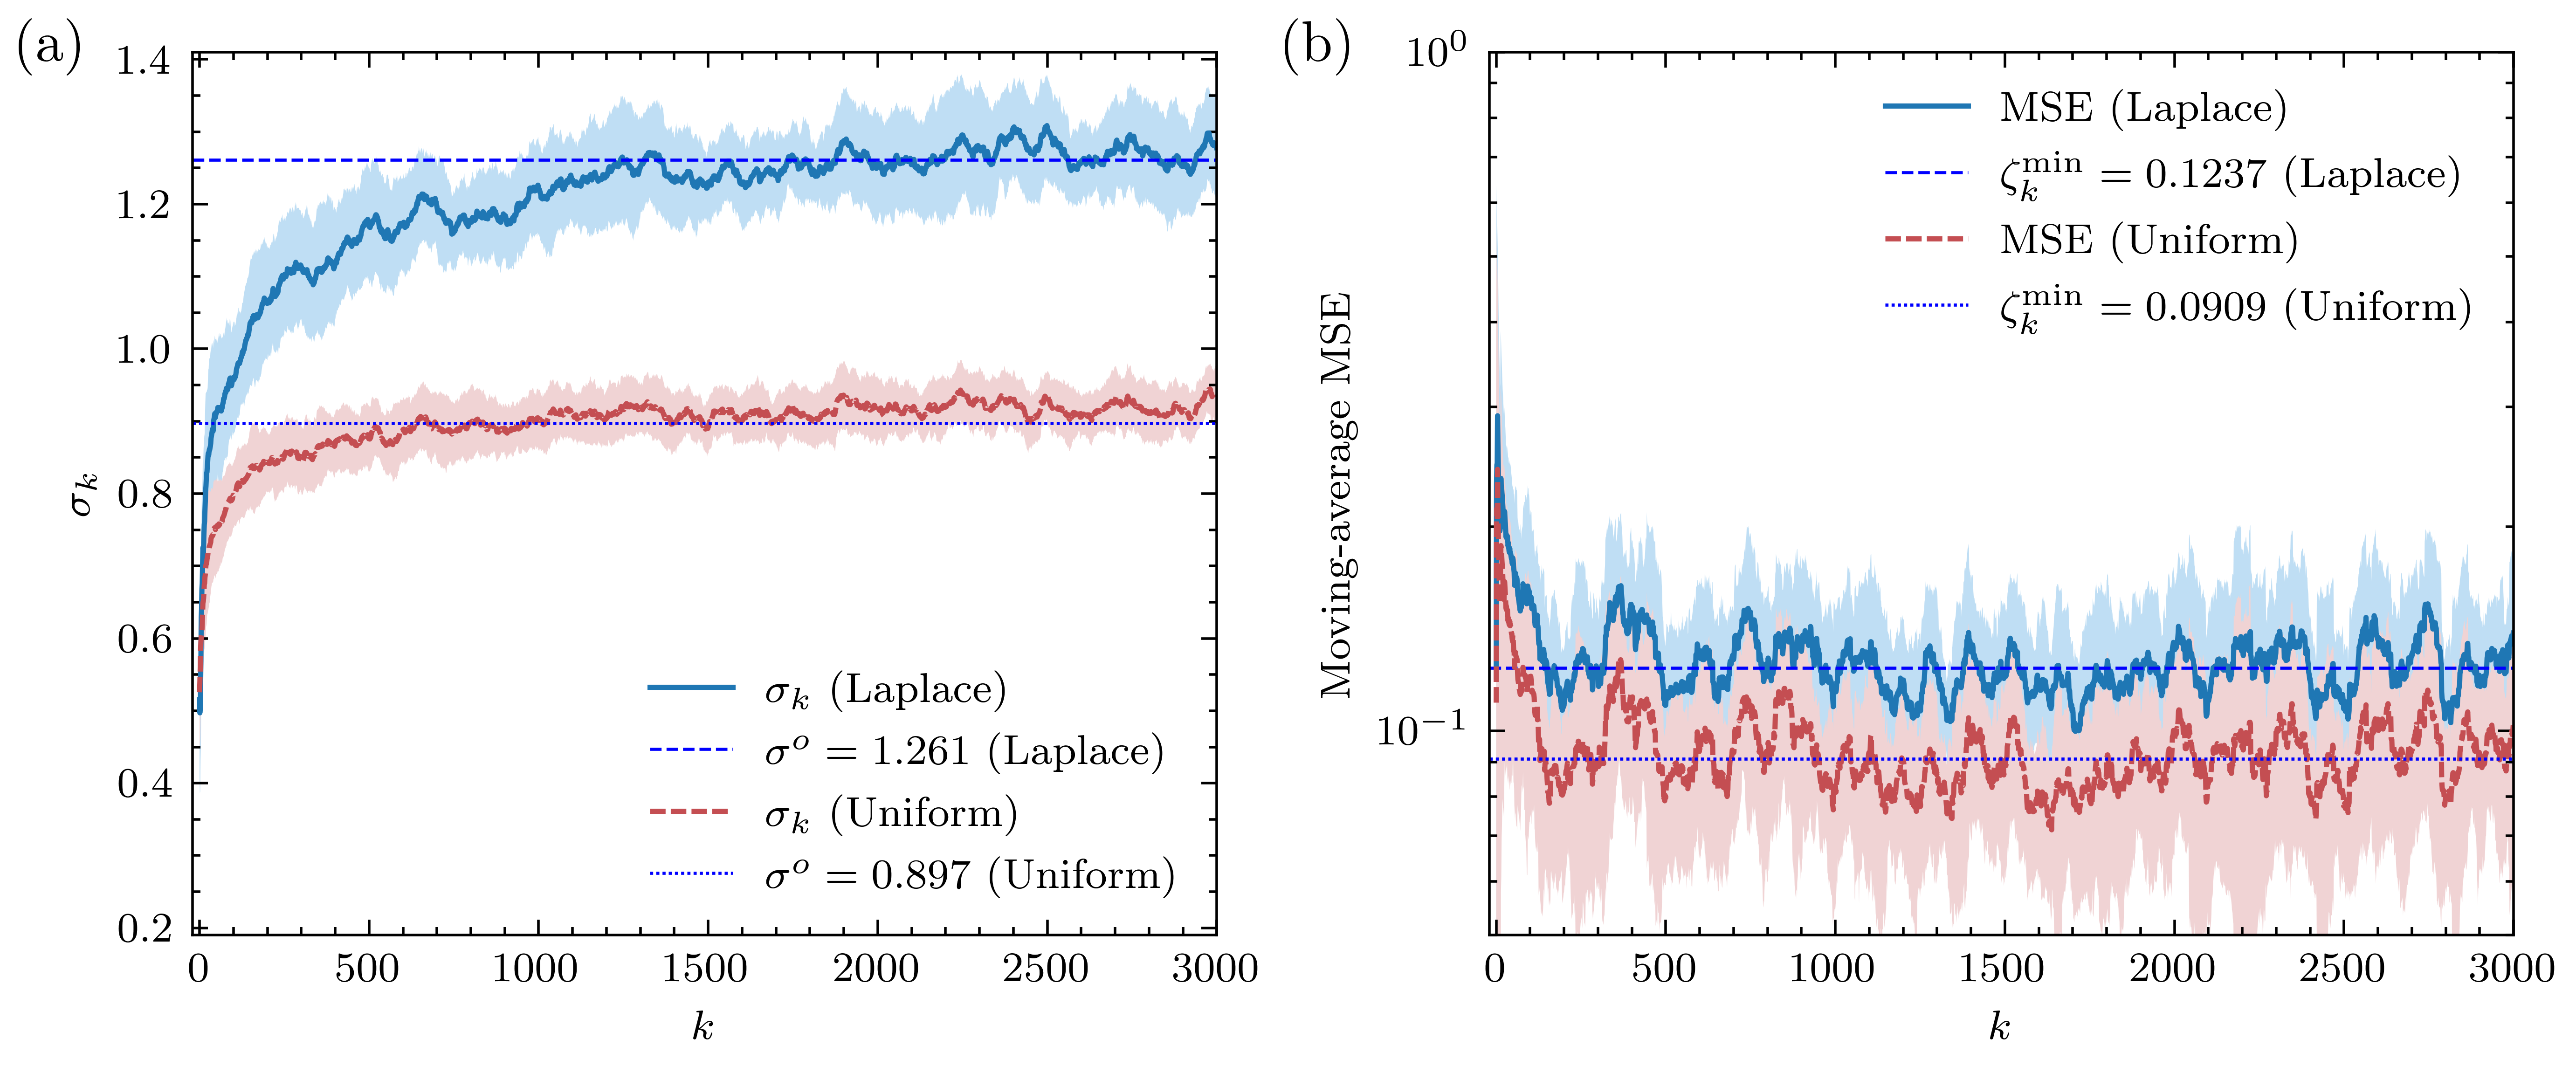


Noise            sigma_ss      MSE_exp     MSE_th
------------------------------------------------
Laplace     1.2639±0.0652     0.12379     0.12372
Uniform     0.9171±0.0377     0.09104     0.09091


In [29]:
# ── 绘图风格 ──────────────────────────────────────────
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 8,
    'axes.labelsize'    : 8,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 800,
    'axes.unicode_minus': False,
})

# ── 配色辅助函数 ──────────────────────────────────────
def lighten_color(color, amount=0.7):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount*(1-c[1]), c[2])
k_arr = np.arange(Nx_total)

fig, (ax_s, ax_m) = plt.subplots(1, 2, figsize=(7, 3))

linestyles = {
    'Laplace': {'exp': '-',         'theory': '--'},
    'Uniform': {'exp': (0,(3,1)),   'theory': (0,(1,1))},
}

for name, cfg in noise_configs.items():
    d         = results[name]
    c         = cfg['color']
    lc        = cfg['light_color']
    lbl       = cfg['label']
    ls_exp    = linestyles[name]['exp']
    ls_th     = linestyles[name]['theory']
    sigma_opt, mse_opt = theory_vals[name]

    # (a) sigma_k：阴影在曲线之下
    ax_s.fill_between(k_arr,
                      d['sigma_mean'] - d['sigma_std'],
                      d['sigma_mean'] + d['sigma_std'],
                      color=lc, edgecolor='none')
    ax_s.plot(k_arr, d['sigma_mean'],
              color=c, lw=1.0, linestyle=ls_exp,
              label=rf'$\sigma_k$ ({lbl})')
    ax_s.axhline(sigma_opt,
                 color='blue', lw=0.6, linestyle=ls_th,
                 label=rf'$\sigma^o = {sigma_opt:.3f}$ ({lbl})')

    # (b) MSE（log 轴）：阴影在曲线之下
    ax_m.fill_between(k_arr,
                      np.maximum(d['mse_mean'] - d['mse_std'], 1e-4),
                      d['mse_mean'] + d['mse_std'],
                      color=lc, edgecolor='none')
    ax_m.plot(k_arr, d['mse_mean'],
              color=c, lw=1.0, linestyle=ls_exp,
              label=rf'MSE ({lbl})')
    ax_m.axhline(mse_opt,
                 color='blue', lw=0.6, linestyle=ls_th,
                 label=rf'$\zeta_k^{{\rm min}} = {mse_opt:.4f}$ ({lbl})')

# (a) 格式
ax_s.set_xlim([-20, Nx_total])
ax_s.set_ylim([0.19, 1.41])
ax_s.set_xlabel(r'$k$')
ax_s.set_ylabel(r'$\sigma_k$')
ax_s.legend(loc='lower right')
ax_s.text(-0.17, 0.99, '(a)', transform=ax_s.transAxes,
          fontsize=11)

# (b) 格式：log 轴
ax_m.set_xlim([-20, Nx_total])
ax_m.set_ylim([0.05, 1])
ax_m.set_yscale('log')
ax_m.set_xlabel(r'$k$')
ax_m.set_ylabel(r'Moving-average MSE')
ax_m.legend(loc='upper right')
ax_m.text(-0.2, 0.99, '(b)', transform=ax_m.transAxes,
          fontsize=11)

plt.tight_layout()
fig.savefig(
    'D:/IEEE 2025 Adaptive weighted SSR/FigLapuni.eps',
    format='eps',
    dpi=800,
    bbox_inches='tight'
)
plt.show()

# ── 稳态统计 ──────────────────────────────────────────
print()
print(f"{'Noise':<10} {'sigma_ss':>14} {'MSE_exp':>12} {'MSE_th':>10}")
print("-"*48)
for name, cfg in noise_configs.items():
    sigma_opt, mse_opt = theory_vals[name]
    d       = results[name]
    ss      = d['sigma_mean'][steady_idx:].mean()
    ss_std  = d['sigma_std'][steady_idx:].mean()
    mse_val = d['mse_mean'][steady_idx:].mean()
    print(f"{name:<10} {ss:>7.4f}±{ss_std:<5.4f}  "
          f"{mse_val:>10.5f}  {mse_opt:>10.5f}")